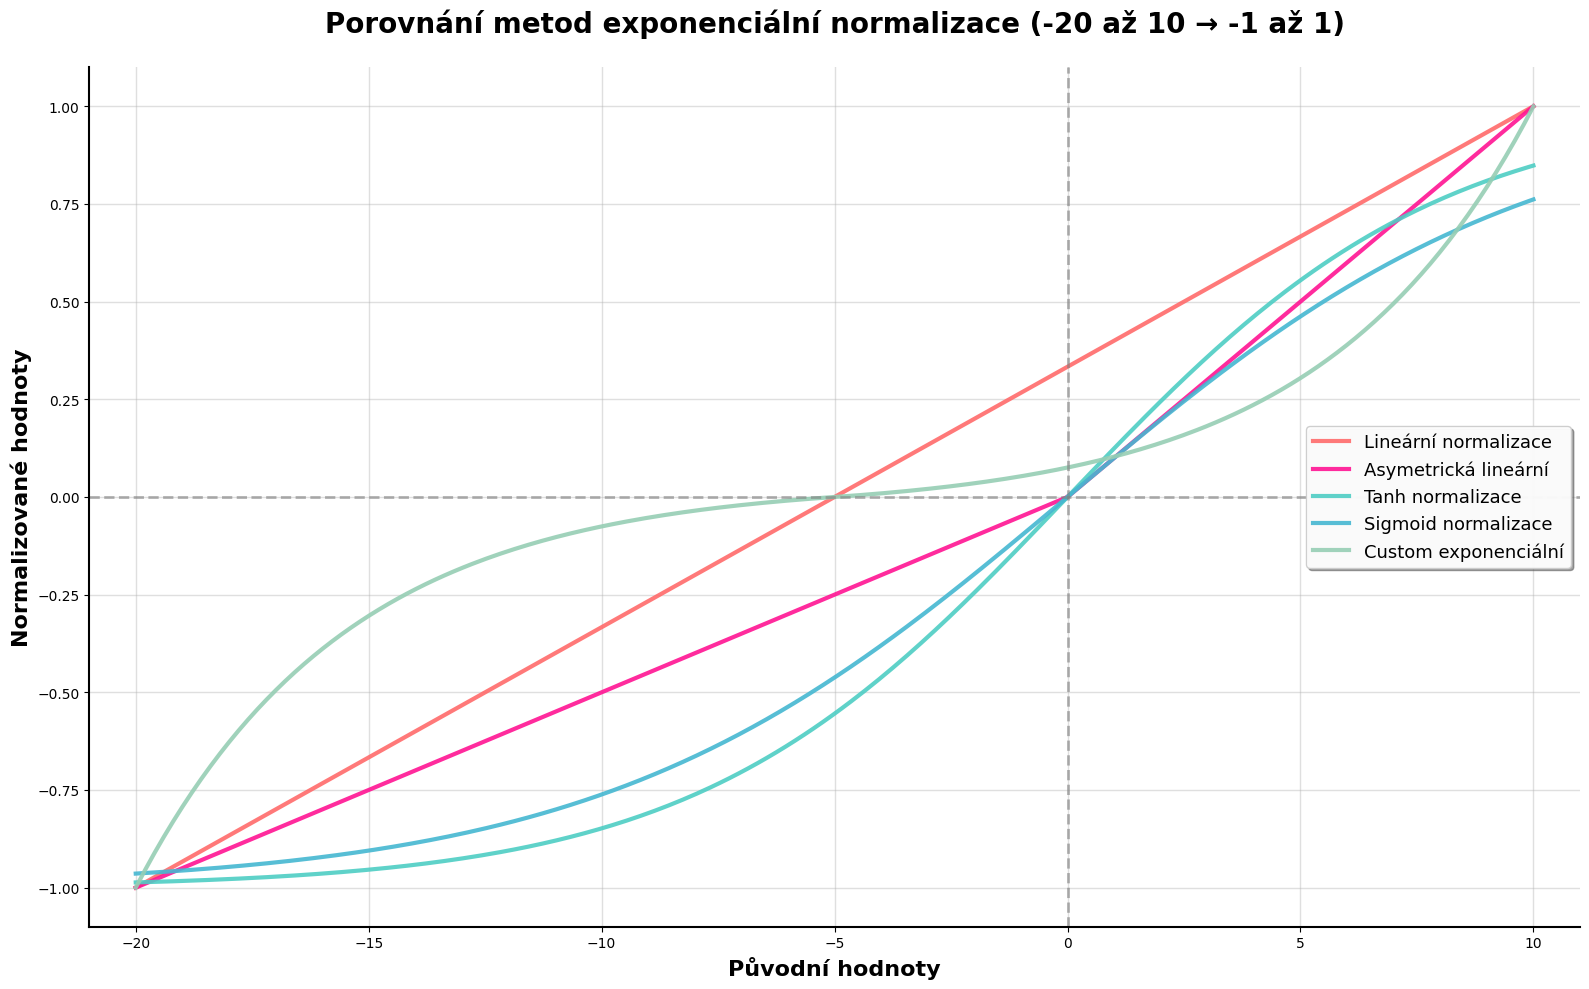

POROVNÁNÍ METOD V KLÍČOVÝCH BODECH
Původní  Lineární   Asym.Lin.  Tanh       Sigmoid    Custom     Asym.Sig. 
--------------------------------------------------------------------------------


TypeError: 'int' object is not subscriptable

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Vytvoření dat
x = np.linspace(-20, 10, 300)  # Původní rozsah hodnot

# Definice normalizačních funkcí
def linear_normalize(x, min_val=-20, max_val=10):
    """Lineární normalizace do (-1, 1)"""
    return (x - min_val) / (max_val - min_val) * 2 - 1

def asymmetric_linear_normalize(x, min_val=-20, max_val=10):
    x = np.asarray(x)
    result = np.zeros_like(x)

    # Záporné hodnoty (min_val až 0) → (-1 až 0)
    neg_mask = x <= 0
    if np.any(neg_mask):
        neg_values = x[neg_mask]
        # Min-max normalizace záporných hodnot do (-1, 0)
        result[neg_mask] = -(neg_values - min_val) / (0 - min_val) * (-1) -1

    # Kladné hodnoty (0 až max_val) → (0 až 1)
    pos_mask = x > 0
    if np.any(pos_mask):
        pos_values = x[pos_mask]
        # Min-max normalizace kladných hodnot do (0, 1)
        result[pos_mask] = (pos_values - 0) / (max_val - 0) * 1 + 0

    return result

def tanh_normalize(x, scale=8.0):
    """Tanh normalizace"""
    return np.tanh(x / scale)

def sigmoid_normalize(x, alpha=0.2):
    """Sigmoid normalizace"""
    return 2 / (1 + np.exp(-alpha * x)) - 1

def exponential_normalize(x, min_val=-20, max_val=10, sharpness=0.3):
    """Custom exponenciální normalizace"""
    # Lineární normalizace
    linear_norm = (x - min_val) / (max_val - min_val) * 2 - 1

    # Exponenciální transformace
    sign = np.sign(linear_norm)
    abs_norm = np.abs(linear_norm)
    exp_transform = (np.exp(abs_norm / sharpness) - 1) / (np.exp(1/sharpness) - 1)

    return sign * exp_transform


# Aplikace normalizací
y_linear = linear_normalize(x)
y_asymmetric_linear = asymmetric_linear_normalize(x)
y_tanh = tanh_normalize(x, scale=8.0)
y_sigmoid = sigmoid_normalize(x, alpha=0.2)
y_exponential = exponential_normalize(x, sharpness=0.3)

# Vytvoření hlavního grafu
plt.figure(figsize=(16, 10))

plt.plot(x, y_linear, label='Lineární normalizace', linewidth=3, color='#FF6B6B', alpha=0.9)
plt.plot(x, y_asymmetric_linear, label='Asymetrická lineární', linewidth=3, color='#FF1493', alpha=0.9)
plt.plot(x, y_tanh, label='Tanh normalizace', linewidth=3, color='#4ECDC4', alpha=0.9)
plt.plot(x, y_sigmoid, label='Sigmoid normalizace', linewidth=3, color='#45B7D1', alpha=0.9)
plt.plot(x, y_exponential, label='Custom exponenciální', linewidth=3, color='#96CEB4', alpha=0.9)

plt.axhline(y=0, color='gray', linestyle='--', alpha=0.6, linewidth=2)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.6, linewidth=2)
plt.grid(True, alpha=0.4, linewidth=1)

plt.xlabel('Původní hodnoty', fontsize=16, fontweight='bold')
plt.ylabel('Normalizované hodnoty', fontsize=16, fontweight='bold')
plt.title('Porovnání metod exponenciální normalizace (-20 až 10 → -1 až 1)',
          fontsize=20, fontweight='bold', pad=25)

plt.legend(fontsize=13, framealpha=0.95, loc='right', shadow=True)
plt.ylim(-1.1, 1.1)
plt.xlim(-21, 11)

# Styling
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(1.5)
plt.gca().spines['bottom'].set_linewidth(1.5)

plt.tight_layout()
plt.show()

# Porovnání hodnot v klíčových bodech
print("POROVNÁNÍ METOD V KLÍČOVÝCH BODECH")
print("=" * 80)
print(f"{'Původní':<8} {'Lineární':<10} {'Asym.Lin.':<10} {'Tanh':<10} {'Sigmoid':<10} {'Custom':<10} {'Asym.Sig.':<10}")
print("-" * 80)

test_values = [-20, -10, -5, -2, -1, 0, 1, 2, 5, 10]

for val in test_values:
    lin_val = linear_normalize(val)
    asym_lin_val = asymmetric_linear_normalize(val)
    tanh_val = tanh_normalize(val, scale=8.0)
    sig_val = sigmoid_normalize(val, alpha=0.2)
    exp_val = exponential_normalize(val, sharpness=0.3)
    asym_sig_val = asymmetric_normalize(val, neg_alpha=0.15, pos_alpha=0.3)

    # Extrahovat skalární hodnoty z numpy arrays
    lin_val = float(lin_val) if hasattr(lin_val, '__iter__') else lin_val
    asym_lin_val = float(asym_lin_val) if hasattr(asym_lin_val, '__iter__') else asym_lin_val
    tanh_val = float(tanh_val) if hasattr(tanh_val, '__iter__') else tanh_val
    sig_val = float(sig_val) if hasattr(sig_val, '__iter__') else sig_val
    exp_val = float(exp_val) if hasattr(exp_val, '__iter__') else exp_val
    asym_sig_val = float(asym_sig_val) if hasattr(asym_sig_val, '__iter__') else asym_sig_val

    print(f"{val:<8.0f} "
          f"{lin_val:<10.3f} "
          f"{asym_lin_val:<10.3f} "
          f"{tanh_val:<10.3f} "
          f"{sig_val:<10.3f} "
          f"{exp_val:<10.3f} "
          f"{asym_sig_val:<10.3f}")

print("\nPARAMETRY METOD:")
print("• Asymetrická lineární: 70% rozsahu pro záporné, 30% pro kladné hodnoty")
print("• Tanh: škála = 8.0")
print("• Sigmoid: α = 0.2")
print("• Custom exponenciální: sharpness = 0.3")
print("• Asymetrická sigmoid: α_záp = 0.15, α_klad = 0.3")